In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 中文字体设置
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

from features import preprocess_features, select_features
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve, average_precision_score,
                             recall_score, f1_score, precision_score, make_scorer,
                             roc_auc_score)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline as SkPipeline
from scipy.stats import randint, uniform
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [70]:
df = pd.read_csv(r"D:/projects/项目复现/telecom_data.csv")

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [72]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


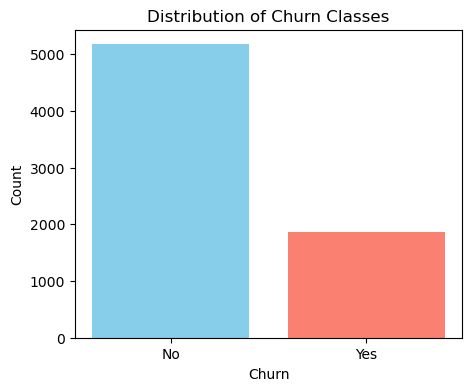

In [73]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(5, 4))
plt.bar(churn_counts.index, churn_counts.values, color=['skyblue', 'salmon'])
plt.title('Distribution of Churn Classes')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(churn_counts.index, churn_counts.index)
plt.show()

## 数据分割

In [74]:
# 标准化列名（小写、去空格）
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

# 处理目标列
df['churn'] = (df['churn'].str.lower().str.strip().map({'yes': 1, 'no': 0})).astype('int64')

# 分割数据集
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['churn']
)
print(f"Data split completed - Train: {len(train_df)}, Test: {len(test_df)}")

Data split completed - Train: 5634, Test: 1409


## 特征预处理

In [75]:
train_df=preprocess_features(train_df)
test_df=preprocess_features(test_df)

In [76]:
train_df.head()

,gender,seniorcitizen,phoneservice,multiplelines,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,...,high_risk_payment,single_customer,family_customer,contract_One_year,contract_Two_year,internetservice_Fiber_optic,internetservice_No,paymentmethod_Credit_card_(automatic),paymentmethod_Electronic_check,paymentmethod_Mailed_check
3738,1,0,0,0,0,0,1,0,1,1,...,1,1,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3151,1,0,1,0,1,0,0,0,0,0,...,0,0,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4860,1,0,0,0,1,1,0,1,0,0,...,0,0,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3867,0,0,1,0,0,1,1,0,1,1,...,0,0,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3810,1,0,1,0,0,0,0,0,0,0,...,1,0,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [77]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 5634 non-null   int64  
 1   seniorcitizen                          5634 non-null   int64  
 2   phoneservice                           5634 non-null   int64  
 3   multiplelines                          5634 non-null   int64  
 4   onlinesecurity                         5634 non-null   int64  
 5   onlinebackup                           5634 non-null   int64  
 6   deviceprotection                       5634 non-null   int64  
 7   techsupport                            5634 non-null   int64  
 8   streamingtv                            5634 non-null   int64  
 9   streamingmovies                        5634 non-null   int64  
 10  paperlessbilling                       5634 non-null   int64  
 11  monthl

## 特征选择

In [78]:
selected_train_df, selected_features = select_features(train_df,target_col='churn', k=15)

In [79]:
selected_features

['onlinesecurity',
 'paperlessbilling',
 'monthlycharges',
 'totalcharges',
 'tenure_year',
 'is_month_to_month',
 'has_long_contract',
 'service_bundle_score',
 'high_monthly_charges',
 'high_risk_payment',
 'contract_One_year',
 'contract_Two_year',
 'internetservice_Fiber_optic',
 'internetservice_No',
 'paymentmethod_Electronic_check']

In [80]:
selected_train_df.head()

,onlinesecurity,paperlessbilling,monthlycharges,totalcharges,tenure_year,is_month_to_month,has_long_contract,service_bundle_score,high_monthly_charges,high_risk_payment,contract_One_year,contract_Two_year,internetservice_Fiber_optic,internetservice_No,paymentmethod_Electronic_check,churn
3738,0.0,0.0,49.20,1701.65,2.916667,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
3151,1.0,0.0,75.10,1151.55,1.250000,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0
4860,1.0,0.0,40.55,590.35,1.083333,0.0,1.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
3867,0.0,1.0,73.50,1905.70,2.166667,0.0,1.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0
3810,0.0,0.0,44.55,44.55,0.083333,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0


In [81]:
selected_test_df= test_df[selected_features + ['churn']]

In [82]:
selected_test_df.head()

,onlinesecurity,paperlessbilling,monthlycharges,totalcharges,tenure_year,is_month_to_month,has_long_contract,service_bundle_score,high_monthly_charges,high_risk_payment,contract_One_year,contract_Two_year,internetservice_Fiber_optic,internetservice_No,paymentmethod_Electronic_check,churn
437,1,1,114.05,8468.20,6.000000,0,1,4,1,0,0.0,1.0,1.0,0.0,0.0,0
2280,0,1,100.15,908.55,0.666667,1,0,1,1,0,0.0,0.0,1.0,0.0,0.0,0
2235,1,1,78.35,3211.20,3.416667,0,1,3,1,0,1.0,0.0,0.0,0.0,0.0,0
4460,0,0,78.20,1468.75,1.500000,1,0,2,1,1,0.0,0.0,1.0,0.0,1.0,0
3761,1,1,82.65,5919.35,6.000000,0,1,3,1,0,0.0,1.0,0.0,0.0,0.0,0


In [83]:
X_train= selected_train_df.drop('churn', axis=1)
y_train = selected_train_df['churn']
X_test = selected_test_df.drop('churn', axis=1)
y_test = selected_test_df['churn']

## 标准化处理

In [84]:
# 自动识别连续特征（非二值列）
binary_mask = X_train.apply(lambda col: set(col.dropna().unique()).issubset({0, 1}))
continuous_cols = [col for col in X_train.columns if not binary_mask[col]]
print(f"连续特征 ({len(continuous_cols)} 列): {continuous_cols}")

# 标准化连续特征
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled = X_test.copy()
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

# 让 X_train, X_test 指向标准化后的数据
X_train = X_train_scaled
X_test = X_test_scaled
print("标准化完成")

连续特征 (4 列): ['monthlycharges', 'totalcharges', 'tenure_year', 'service_bundle_score']
标准化完成


In [88]:
X_train.head()

,onlinesecurity,paperlessbilling,monthlycharges,totalcharges,tenure_year,is_month_to_month,has_long_contract,service_bundle_score,high_monthly_charges,high_risk_payment,contract_One_year,contract_Two_year,internetservice_Fiber_optic,internetservice_No,paymentmethod_Electronic_check
3738,0.0,0.0,-0.521976,-0.263290,0.102371,1.0,0.0,-0.215513,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3151,1.0,0.0,0.337478,-0.504815,-0.711743,1.0,0.0,-0.215513,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4860,1.0,0.0,-0.809013,-0.751214,-0.793155,0.0,1.0,1.337171,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3867,0.0,1.0,0.284384,-0.173700,-0.263980,0.0,1.0,0.560829,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3810,0.0,0.0,-0.676279,-0.990851,-1.281624,1.0,0.0,-0.991854,0.0,1.0,0.0,0.0,0.0,0.0,1.0


## 类别不平衡处理策略对比

In [105]:
# ============================================================
# 类别不平衡处理策略对比实验
# 3种策略 × 3种模型 × 超参数搜索（5-Fold CV）
# 策略: 不处理 / Class Weight / SMOTE
# 模型: Logistic Regression / Random Forest / XGBoost
# ============================================================

# --- 超参数搜索空间 ---
param_logreg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['saga'],
    'random_state': [42]
}
param_rf = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(5, 15),
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 8),
    'bootstrap': [True, False],
    'random_state': [42]
}
param_xgb = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.19),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0, 0.1, 1],
    'random_state': [42]
}

# --- 评估指标 ---
churn_recall_scorer = make_scorer(recall_score, pos_label=1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- 策略 & 模型定义 ---
strategies = ['none', 'class_weight', 'smote']
model_types = ['logreg', 'rf', 'xgb']
model_names = {'logreg': 'Logistic Regression', 'rf': 'Random Forest', 'xgb': 'XGBoost'}
strategy_names = {'none': '不处理', 'class_weight': 'Class Weight', 'smote': 'SMOTE'}

def build_model(mtype, strategy):
    """根据策略构建模型（含 class_weight / scale_pos_weight）"""
    if mtype == 'logreg':
        if strategy == 'class_weight':
            return LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
        return LogisticRegression(max_iter=1000, random_state=42)
    elif mtype == 'rf':
        if strategy == 'class_weight':
            return RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
        return RandomForestClassifier(n_estimators=100, random_state=42)
    elif mtype == 'xgb':
        if strategy == 'class_weight':
            spw = (y_train == 0).sum() / (y_train == 1).sum()
            return XGBClassifier(n_estimators=100, scale_pos_weight=spw,
                                  verbosity=0, eval_metric='logloss', random_state=42)
        return XGBClassifier(n_estimators=100, verbosity=0,
                              eval_metric='logloss', random_state=42)

def build_pipeline(strategy, model):
    """构建 Pipeline: [SMOTE] + 模型"""
    steps = []
    if strategy == 'smote':
        steps.append(('smote', SMOTE(random_state=42)))
    steps.append(('model', model))
    return ImbPipeline(steps) if strategy == 'smote' else SkPipeline(steps)

# --- 1) Baseline: 默认参数 CV（仅 churn_recall） ---
print("=" * 60)
print("Baseline - 默认参数 5-Fold CV (Churn Recall)")
print("=" * 60)
baseline_scores = {}
for strategy in strategies:
    for mtype in model_types:
        model = build_model(mtype, strategy)
        pipe = build_pipeline(strategy, model)
        scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                                  scoring=churn_recall_scorer, n_jobs=1)
        baseline_scores[(strategy, mtype)] = scores.mean()
        print(f"  {strategy_names[strategy]:>12s} + {model_names[mtype]:<20s}: {scores.mean():.4f} ± {scores.std():.4f}")

# --- 2) 超参数搜索 ---
print("\n" + "=" * 60)
print("超参数搜索")
print("=" * 60)
best_pipelines = {}
search_cv_scores = {}

for strategy in strategies:
    for mtype in model_types:
        print(f"\n策略: {strategy_names[strategy]} | 模型: {model_names[mtype]}")
        
        if mtype == 'logreg':
            param_dist = param_logreg
            n_iter = None
        elif mtype == 'rf':
            param_dist = param_rf
            n_iter = 15
        else:
            param_dist = param_xgb
            n_iter = 15
        
        search_model = build_model(mtype, strategy)
        search_pipeline = build_pipeline(strategy, search_model)
        prefixed_params = {f'model__{k}': v for k, v in param_dist.items()}
        
        if mtype == 'logreg':
            search = GridSearchCV(
                estimator=search_pipeline,
                param_grid=prefixed_params,
                cv=cv, scoring=churn_recall_scorer,
                refit=True, verbose=0, n_jobs=1
            )
        else:
            search = RandomizedSearchCV(
                estimator=search_pipeline,
                param_distributions=prefixed_params,
                n_iter=n_iter, cv=cv, scoring=churn_recall_scorer,
                refit=True, verbose=0, random_state=42, n_jobs=1
            )
        search.fit(X_train, y_train)
        
        best_pipelines[(strategy, mtype)] = search.best_estimator_
        search_cv_scores[(strategy, mtype)] = search.best_score_
        print(f"  Best CV churn_recall: {search.best_score_:.4f} (baseline: {baseline_scores[(strategy, mtype)]:.4f})")
        print(f"  Best params: {search.best_params_}")

print("\n\n全部完成！")

Baseline - 默认参数 5-Fold CV (Churn Recall)
           不处理 + Logistic Regression : 0.5385 ± 0.0313
           不处理 + Random Forest       : 0.4977 ± 0.0187
           不处理 + XGBoost             : 0.5211 ± 0.0198
  Class Weight + Logistic Regression : 0.7993 ± 0.0288
  Class Weight + Random Forest       : 0.4983 ± 0.0201
  Class Weight + XGBoost             : 0.6736 ± 0.0205
         SMOTE + Logistic Regression : 0.7967 ± 0.0277
         SMOTE + Random Forest       : 0.6127 ± 0.0131
         SMOTE + XGBoost             : 0.6722 ± 0.0277

超参数搜索

策略: 不处理 | 模型: Logistic Regression
  Best CV churn_recall: 0.5418 (baseline: 0.5385)
  Best params: {'model__C': 100, 'model__penalty': 'l1', 'model__random_state': 42, 'model__solver': 'saga'}

策略: 不处理 | 模型: Random Forest
  Best CV churn_recall: 0.5278 (baseline: 0.4977)
  Best params: {'model__bootstrap': False, 'model__max_depth': 12, 'model__min_samples_leaf': 4, 'model__min_samples_split': 3, 'model__n_estimators': 233, 'model__random_state': 42}



类别不平衡处理策略对比 - Baseline vs 超参数搜索后 (CV Churn Recall)
    Strategy               Model  Baseline  After Tuning  Improvement
         不处理 Logistic Regression  0.538462      0.541806     0.003344
         不处理       Random Forest  0.497659      0.527759     0.030100
         不处理             XGBoost  0.521070      0.523077     0.002007
Class Weight Logistic Regression  0.799331      0.800669     0.001338
Class Weight       Random Forest  0.498328      0.806020     0.307692
Class Weight             XGBoost  0.673579      0.820736     0.147157
       SMOTE Logistic Regression  0.796656      0.796656     0.000000
       SMOTE       Random Forest  0.612709      0.800669     0.187960
       SMOTE             XGBoost  0.672241      0.812040     0.139799


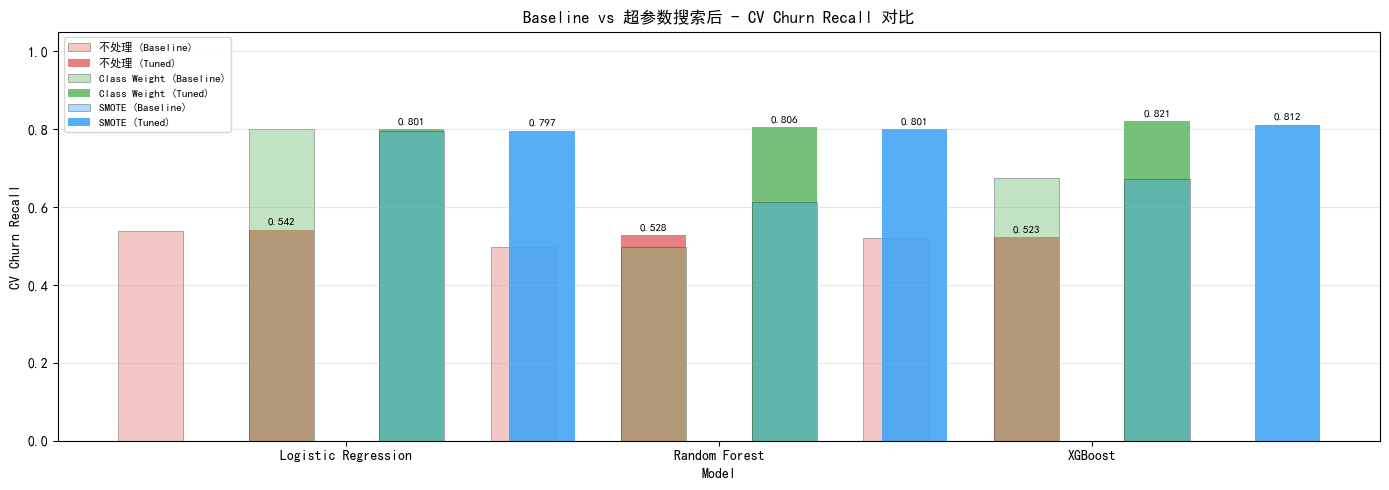

In [106]:
# ============================================================
# 结果对比 - Baseline vs 调参后
# ============================================================

# 1. 对比表格
print("=" * 80)
print("类别不平衡处理策略对比 - Baseline vs 超参数搜索后 (CV Churn Recall)")
print("=" * 80)

search_results = []
for (strategy, mtype), cv_score in search_cv_scores.items():
    baseline = baseline_scores[(strategy, mtype)]
    search_results.append({
        'Strategy': strategy_names[strategy],
        'Model': model_names[mtype],
        'Baseline': baseline,
        'After Tuning': cv_score,
        'Improvement': cv_score - baseline
    })

search_df = pd.DataFrame(search_results)
print(search_df.to_string(index=False))

# 2. 分组柱状图: Baseline vs 调参后
bar_colors = {'不处理': '#E57373', 'Class Weight': '#66BB6A', 'SMOTE': '#42A5F5'}
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(model_types))
width = 0.35

for i, strategy in enumerate(strategies):
    baselines = []
    tuned = []
    for mtype in model_types:
        row = search_df[(search_df['Strategy'] == strategy_names[strategy]) &
                        (search_df['Model'] == model_names[mtype])]
        baselines.append(row['Baseline'].values[0])
        tuned.append(row['After Tuning'].values[0])
    
    # Baseline（浅色）
    bars1 = ax.bar(x + i * width - width/2, baselines, width/2,
                   label=f'{strategy_names[strategy]} (Baseline)',
                   color=bar_colors[strategy_names[strategy]], alpha=0.4, edgecolor='black', linewidth=0.5)
    # After Tuning（深色）
    bars2 = ax.bar(x + i * width + width/2, tuned, width/2,
                   label=f'{strategy_names[strategy]} (Tuned)',
                   color=bar_colors[strategy_names[strategy]], alpha=0.9)
    
    for bar, m in zip(bars2, tuned):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{m:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model')
ax.set_ylabel('CV Churn Recall')
ax.set_title('Baseline vs 超参数搜索后 - CV Churn Recall 对比')
ax.set_xticks(x + width)
ax.set_xticklabels([model_names[m] for m in model_types])
ax.legend(loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 最优模型评估

最优组合（基于 CV 分数）: Class Weight + XGBoost
CV Churn Recall: 0.8207

测试集验证 - Class Weight + XGBoost
              precision    recall  f1-score   support

        Stay       0.91      0.72      0.80      1035
       Churn       0.51      0.81      0.63       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.81      0.74      0.76      1409

Confusion Matrix:
[[742 293]
 [ 70 304]]

ROC-AUC:  0.8400
PR-AUC:   0.6401
Churn Recall (test): 0.8128


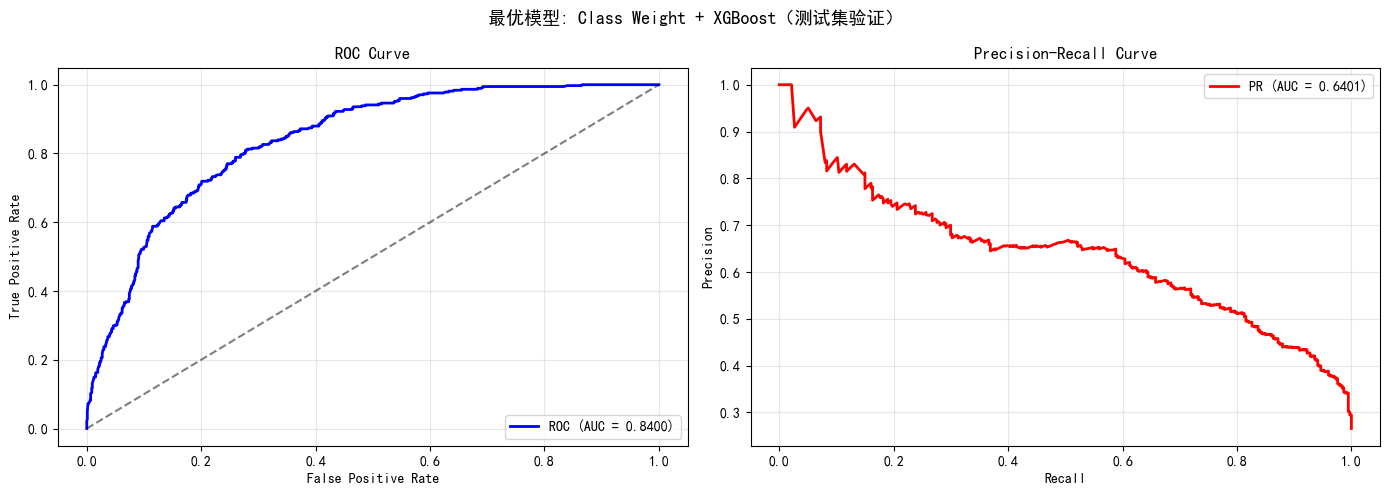

In [108]:
# ============================================================
# 选出最优策略×模型组合（基于 CV 分数），在测试集上验证
# ============================================================

# 选出 CV Churn Recall 最高的组合（避免测试集泄漏）
best_row = search_df.loc[search_df['After Tuning'].idxmax()]
best_strategy = best_row['Strategy']
best_model = best_row['Model']
print(f"最优组合（基于 CV 分数）: {best_strategy} + {best_model}")
print(f"CV Churn Recall: {best_row['After Tuning']:.4f}")

# 找到对应的 pipeline
strategy_key = [k for k in strategy_names if strategy_names[k] == best_strategy][0]
model_key = [k for k in model_names if model_names[k] == best_model][0]
best_pipeline = best_pipelines[(strategy_key, model_key)]

# 测试集验证（仅用于最终确认，不参与模型选择）
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

print("\n" + "=" * 60)
print(f"测试集验证 - {best_strategy} + {best_model}")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Stay', 'Churn']))

print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"\nROC-AUC:  {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, y_proba):.4f}")
print(f"Churn Recall (test): {recall_score(y_test, y_pred):.4f}")

# 可视化: ROC + PR 曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, 'b-', linewidth=2,
             label=f'ROC (AUC = {roc_auc_score(y_test, y_proba):.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# PR
precision, recall, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(recall, precision, 'r-', linewidth=2,
             label=f'PR (AUC = {average_precision_score(y_test, y_proba):.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.suptitle(f'最优模型: {best_strategy} + {best_model}（测试集验证）', fontsize=13)
plt.tight_layout()
plt.show()

## 特征重要性分析

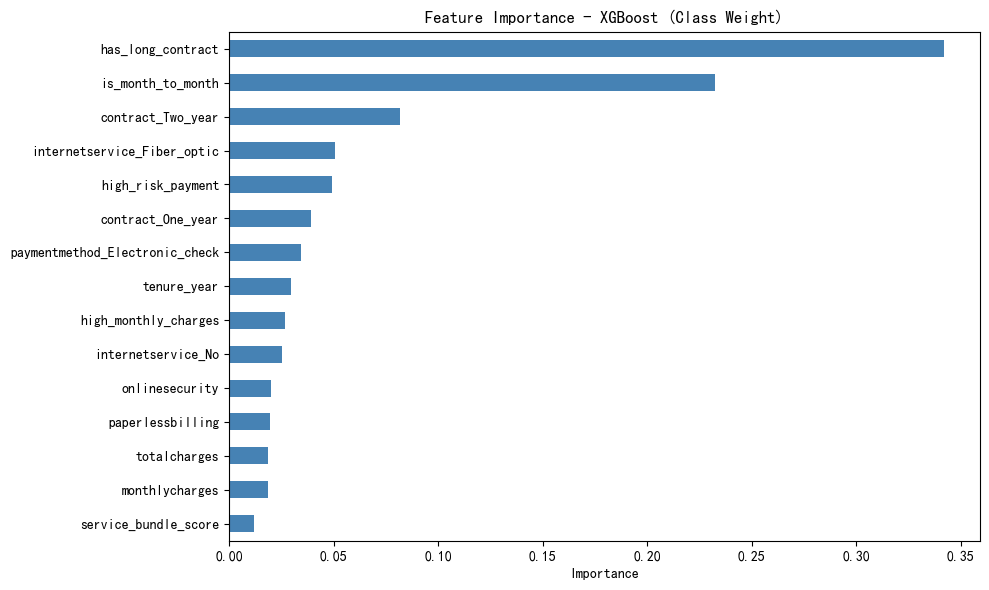


Top 10 Features (XGBoost (Class Weight)):
has_long_contract                 0.342038
is_month_to_month                 0.232425
contract_Two_year                 0.081852
internetservice_Fiber_optic       0.050567
high_risk_payment                 0.049257
contract_One_year                 0.039233
paymentmethod_Electronic_check    0.034391
tenure_year                       0.029490
high_monthly_charges              0.026684
internetservice_No                0.025213


In [98]:
# ============================================================
# 特征重要性分析（基于最优模型）
# ============================================================

# 从最优 pipeline 中提取模型
best_model_obj = best_pipeline.named_steps['model']

# 判断模型类型
if hasattr(best_model_obj, 'feature_importances_'):
    importances = best_model_obj.feature_importances_
    model_label = f"{best_model} ({best_strategy})"
    
    # 排序
    feat_imp = pd.Series(importances, index=selected_features).sort_values(ascending=False)
    
    plt.figure(figsize=(10, 6))
    feat_imp.plot(kind='barh', color='steelblue')
    plt.xlabel('Importance')
    plt.title(f'Feature Importance - {model_label}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print(f"\nTop 10 Features ({model_label}):")
    print(feat_imp.head(10).to_string())
else:
    print(f"模型 {model_label} 不支持 feature_importances_，跳过特征重要性分析。")